In [1]:
# !pip install segmentation-models-pytorch
# !pip install Pillow numpy torchvision torch

In [2]:
import os
import sys

# Auto-detect Colab and fetch data
if 'google.colab' in sys.modules:
    if not os.path.exists("LLMs-and-GenAI-Assignment"):
        !git clone https://github.com/nelsunnel/LLMs-and-GenAI-Assignment.git
    
    # Change directory so all relative paths (Datasets/...) work properly
    os.chdir("LLMs-and-GenAI-Assignment")
    print("Running in Colab: clonded repository and navigated to project root.")
else:
    print("Running locally.")

Running locally.


In [3]:
import os
import glob
from PIL import Image
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import segmentation_models_pytorch as smp

In [4]:
class PathologyDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.img_paths = sorted(glob.glob(os.path.join(data_dir, "*.tif")))
        self.mask_paths = [p.replace(".tif", ".out.png") for p in self.img_paths]
        
        self.transform = transform
        
    def __len__(self):
        return len(self.img_paths)
    
    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        mask_path = self.mask_paths[idx]
        
        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")  # Grayscale image
        
        if self.transform is not None:
            img = self.transform(img)
            # Resize the mask to the same spatial dimensions
            # Nearest neighbor specifically so we only get 0 or 255 values
            mask = transforms.Resize((512, 512), interpolation=transforms.InterpolationMode.NEAREST)(mask)
            
        mask_tensor = transforms.ToTensor()(mask)
        # Binarize masks correctly assuming background is 0 and nuclei are 255
        mask_tensor = (mask_tensor > 0).float() 
        return img, mask_tensor

In [5]:
# The original images are 2000x2000, which will cause CUDA OutOfMemory on most Colab instances.
# Thus, we're resizing the input to 512x512.
import platform

transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = PathologyDataset('Datasets/pathologyData/train', transform=transform)
test_dataset = PathologyDataset('Datasets/pathologyData/test', transform=transform)

# Windows multiprocessing in notebooks is fragile; use single-worker to avoid crashes.
if platform.system() == 'Windows':
    num_workers = 0
else:
    num_workers = 2

# Using generic dataloaders
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False, num_workers=num_workers)

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# We create the requested U-Net with ResNet-18 Backbone
model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1, # Binary segmentation since it predicts only nucleus vs background
)
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Using device: cuda


In [7]:
# Training block
num_epochs = 20
print(f"Starting Training for {num_epochs} Epochs...")

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for batch_idx, (images, masks) in enumerate(train_loader):
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

Starting Training for 20 Epochs...
Epoch [1/20], Loss: 0.7265
Epoch [2/20], Loss: 0.6087
Epoch [3/20], Loss: 0.5323
Epoch [4/20], Loss: 0.4776
Epoch [5/20], Loss: 0.4343
Epoch [6/20], Loss: 0.4011
Epoch [7/20], Loss: 0.3786
Epoch [8/20], Loss: 0.3552
Epoch [9/20], Loss: 0.3375
Epoch [10/20], Loss: 0.3157
Epoch [11/20], Loss: 0.3056
Epoch [12/20], Loss: 0.2949
Epoch [13/20], Loss: 0.2830
Epoch [14/20], Loss: 0.2759
Epoch [15/20], Loss: 0.2654
Epoch [16/20], Loss: 0.2619
Epoch [17/20], Loss: 0.2559
Epoch [18/20], Loss: 0.2449
Epoch [19/20], Loss: 0.2405
Epoch [20/20], Loss: 0.2331


In [8]:
# Evaluation block to calculate Precision and Recall for the Nucleus class
print("Starting Evaluation on Test Set...")
model.eval()

tp, fp, fn = 0, 0, 0

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)
        
        outputs = model(images)
        preds = (torch.sigmoid(outputs) > 0.5).float() # Binarize predictions and convert to float
        
        # Flatten tensors to speed up true positive computation
        preds_flat = preds.view(-1)
        masks_flat = masks.view(-1)
        
        # Accumulate metrics
        tp += (preds_flat * masks_flat).sum().item()
        fp += (preds_flat * (1 - masks_flat)).sum().item()
        fn += ((1 - preds_flat) * masks_flat).sum().item()

precision = tp / (tp + fp + 1e-8)
recall = tp / (tp + fn + 1e-8)

print(f"Test Set Metrics for Nucleus Class => Precision: {precision:.4f} | Recall: {recall:.4f}")

Starting Evaluation on Test Set...
Test Set Metrics for Nucleus Class => Precision: 0.8315 | Recall: 0.7876


Visualizing some predictions from the test set...


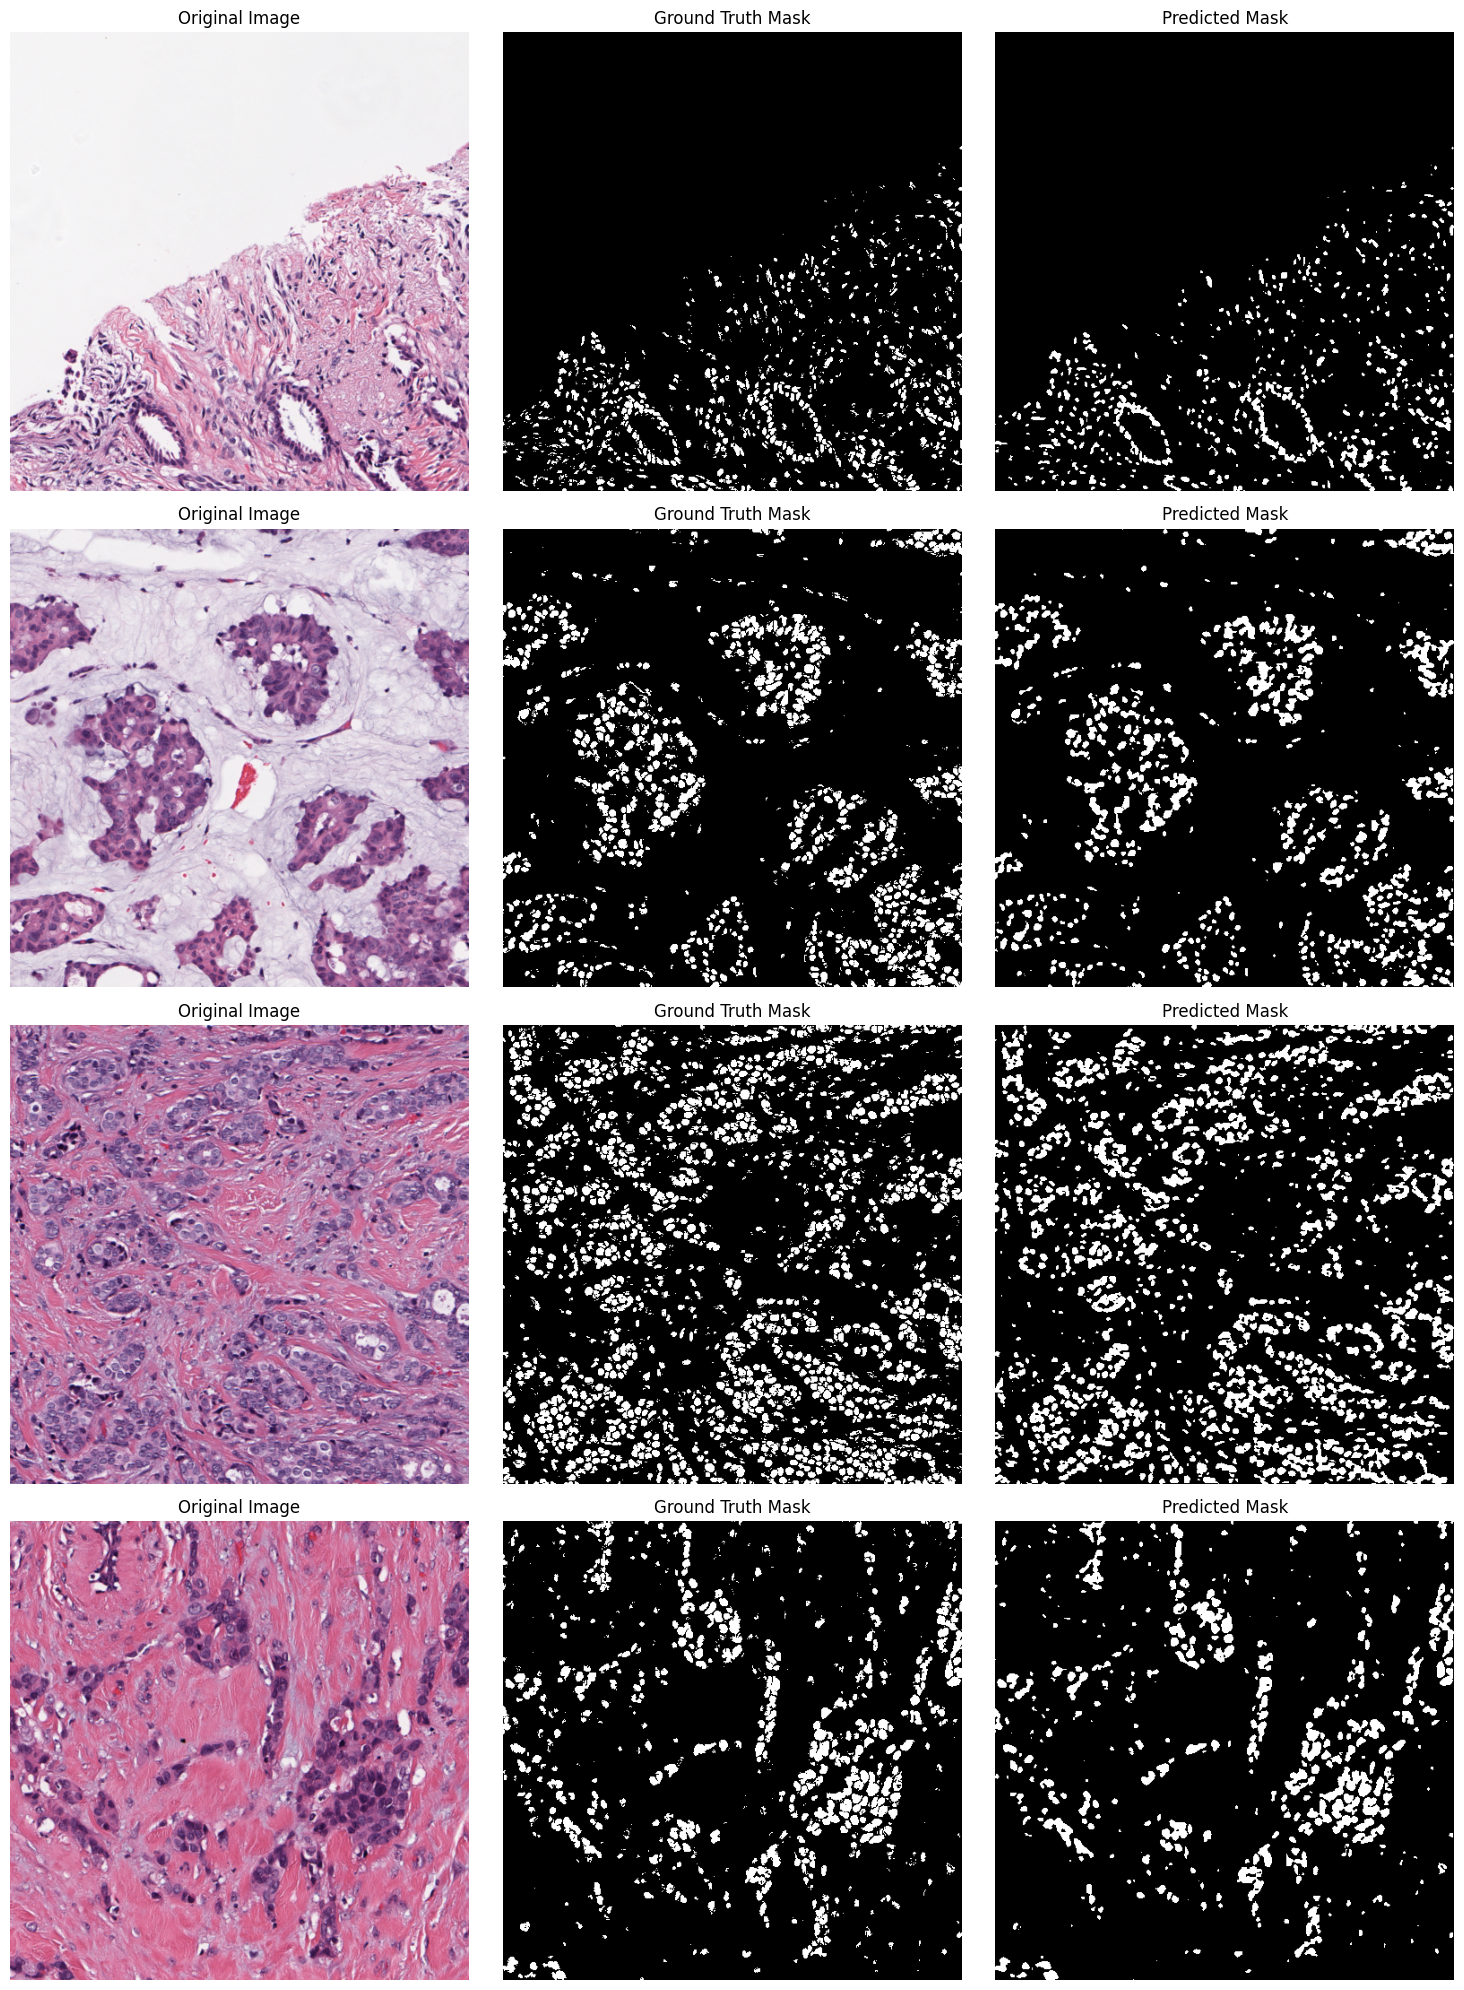

In [ ]:
import matplotlib.pyplot as plt

def visualize_predictions(model, dataset, device, num_samples=3):
    model.eval()
    
    # We will pick a few random indices or just the first few
    indices = np.random.choice(len(dataset), min(num_samples, len(dataset)), replace=False)
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    if num_samples == 1:
        axes = [axes]
        
    # Un-normalize function to view the original image properly
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )

    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, mask = dataset[idx]
            
            # Predict
            output = model(image.unsqueeze(0).to(device))
            pred_mask = torch.sigmoid(output).cpu().squeeze() > 0.5
            
            # Prepare image for plotting
            vis_img = inv_normalize(image).permute(1, 2, 0).cpu().numpy()
            vis_img = np.clip(vis_img, 0, 1) # Ensure values are in [0, 1]
            
            # Prepare masks
            vis_mask = mask.squeeze().numpy()
            vis_pred = pred_mask.numpy()
            
            # Plot
            axes[i][0].imshow(vis_img)
            axes[i][0].set_title('Original Image')
            axes[i][0].axis('off')
            
            axes[i][1].imshow(vis_mask, cmap='gray')
            axes[i][1].set_title('Ground Truth Mask')
            axes[i][1].axis('off')
            
            axes[i][2].imshow(vis_pred, cmap='gray')
            axes[i][2].set_title('Predicted Mask')
            axes[i][2].axis('off')

    plt.tight_layout()
    plt.show()

print("Visualizing some predictions from the test set...")
visualize_predictions(model, test_dataset, device, num_samples=4)